# AI Research Trends — The Citation Target Is Not Learnable, and What This Table Is Good For Instead
> **3,200 papers · 15 columns · `ai_research_papers.csv`** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/ai-ml-research-papers-trends)

The obvious supervised task on this table is "predict `citation_count` from paper
metadata". This notebook runs that task properly — three feature sets across two splits —
and every configuration loses to predicting the median. That is the finding, and it is
reported here rather than buried, because a notebook that quietly picks whichever split
made its model look good is how a non-result gets published as a result.

## TL;DR

- **No model beats the constant baseline.** Best honest configuration on a random split
  is MAE(log1p) **1.3181** against a median baseline of **1.3752** — a 4% edge that
  vanishes entirely on a time-ordered split, where the baseline wins **1.2433 to 1.3891**.
- **Nothing leaks the target, but `paper_id` encodes the date.** It is formatted
  `arxiv.YYYYMM.NNNNN`, and the embedded year and month match the `year` and `month`
  columns for **100%** of rows. Any hash or prefix feature built from it silently
  reintroduces time.
- **Only three columns carry any signal at all**, and adding the other seven makes
  predictions *worse*: MAE rises from **1.3181** to **1.3841** on the same split. Seven
  metadata columns are noise the model overfits.
- **The target is right-censored.** The generator caps citations for the two most recent
  years — max **146** in 2024 and **30** in 2025, against **61,386** in 2023. A
  time-ordered split therefore asks a model to extrapolate into a range the training data
  says is impossible.
- **The heavy tail is extreme.** Median **9** citations, mean **409**, max **126,171**.
  The top 1% of papers hold **63.0%** of all citations, so any per-paper error metric is
  decided by 32 rows.
- **What the table does support is aggregate trend analysis** — the thing its name
  promises. `transformer` goes from **4.2%** of papers in 2018 to **53.1%** in 2025 while
  `rnn` falls from **33.9%** to **1.6%**, and the code-release rate climbs from **35.4%**
  to **62.5%**.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships with
  the dataset. Good for teaching censoring, heavy tails and honest baselines; not
  bibliometric evidence.

## Contents

1. [Setup & data loading](#setup)
2. [Objective & evaluation plan](#objective)
3. [Data overview](#overview)
4. [Missing data](#missing)
5. [The target is a power law](#powerlaw)
6. [Leakage & feasibility audit](#audit)
7. [Distributions](#distributions)
8. [Categoricals](#categorical)
9. [Correlations](#correlations)
10. [Can citations be predicted at all?](#model)
11. [What this table is actually good for](#trends)
12. [Evaluation readiness](#evaluation)
13. [Key findings & takeaways](#findings)

## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 11

MOUNT_GUESS = "/kaggle/input/ai-ml-research-papers-trends"
MARKER = "ai_research_papers.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and falling back
    # to "." landed in the kernel working directory, which holds no CSVs at all,
    # so the notebook died on a confusing FileNotFoundError several cells later.
    # The files mount NESTED (the run that taught us this found only
    # /kaggle/input/datasets). Walk the mount tree for the file we actually
    # need, and if it is absent report what *was* mounted, so the next failure
    # is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
print(f"Reading from: {DATA_DIR}")

Reading from: .


In [2]:
df = pd.read_csv(f"{DATA_DIR}/ai_research_papers.csv")

# Citations are modelled on a log1p scale throughout. On the raw scale a single
# 126,171-citation paper contributes more absolute error than the other 3,199 combined.
df["log_citations"] = np.log1p(df["citation_count"])

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1] - 1} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Years: {df['year'].min()} to {df['year'].max()}   Venues: {df['venue'].nunique()}")
print(f"Categories: {df['category'].nunique()}   Methods: {df['primary_method'].nunique()}")
df.head()

Shape: 3,200 rows x 15 columns
Memory: 2.1 MB
Years: 2018 to 2025   Venues: 9
Categories: 8   Methods: 9


,paper_id,title,abstract,authors,year,month,category,subcategory,citation_count,venue,num_authors,has_code,primary_method,dataset_used,is_survey,log_citations
0,arxiv.202008.00686,Towards Style Transfer with Limited Labels,"In this work, we tackle the problem of graph c...",Andrei Bernard; Benjamin Wu; Carlos Wilson; Pe...,2020,8,cs.CV,image-generation,75,CVPR,6,True,bayesian,Cityscapes,False,4.330733
1,arxiv.202209.01238,End-to-End Neural Architecture Search using Kn...,"This paper presents EfficientAI, designed for ...",Jian Wang; Siddharth Martin; Zhi Sun,2022,9,cs.LG,optimization,240,NeurIPS,3,False,ensemble,CIFAR-10,False,5.484797
2,arxiv.202209.01255,Attention-Based Hyperparameter Optimization us...,This paper introduces ContextFlow for semantic...,Christopher Vinyals; Ian Zhou; Jian Zhang; Mat...,2022,9,cs.LG,meta-learning,42,CVPR,6,True,transformer,CIFAR-100,False,3.761200
3,arxiv.202210.01188,Progressive Point Cloud Processing across Domains,This paper introduces SmartFuse for anomaly de...,Elena Liu; Oriol Petrov; Yoshua Mueller,2022,10,cs.CV,video-understanding,9,CVPR,3,False,reinforcement_learning,CelebA,False,2.302585
4,arxiv.202309.02159,Semi-Supervised Entity Linking via Prompt Tuning,"We propose EfficientAI, a novel approach to te...",Diego Rodriguez; Maria LeCun,2023,9,cs.IR,search-ranking,40,AAAI,2,False,transformer,MovieLens,False,3.713572


## 2. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** predict `citation_count` from paper metadata — venue, category, author
count, code release — and establish whether that is possible at all before reporting a
score for it.

**Metric:** MAE on `log1p(citation_count)`. Raw-scale MAE would be a report on the
handful of papers with five-figure citation counts, and R² on the raw scale is
meaningless for a distribution with this tail.

**Two splits, deliberately:**

| Split | What it simulates | Why it matters here |
|---|---|---|
| Random 5-fold | interpolating within a corpus you already have | flattering, because `year` is shared across folds |
| Time-ordered (train ≤ 2023, test 2024-25) | scoring a paper published today | the realistic one, and the one the target's censoring breaks |

**Baseline to beat:** predicting the median `log1p(citation_count)` for every paper. A
model that cannot beat this has learned nothing, and Section 10 checks that honestly
rather than assuming the model wins.

**Hypothesis under test:** the metadata columns cannot predict per-paper citations,
**because** citation counts here are dominated by a heavy-tailed random draw that no
covariate in the table addresses.

In [3]:
TARGET_COL = "citation_count"
MODELING_TASK = "regression"
PRIMARY_METRIC = "MAE on log1p(citation_count)"

print("Objective framing")
print("-" * 64)
print(f"Rows available      : {len(df):,} papers")
print(f"Target              : {TARGET_COL} (modelled as log1p)")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print()
print(df[TARGET_COL].describe().round(1).to_string())
print()
print("Median vs mean is the whole story:")
print(f"  median {df[TARGET_COL].median():>10,.0f}")
print(f"  mean   {df[TARGET_COL].mean():>10,.0f}   ({df[TARGET_COL].mean() / df[TARGET_COL].median():.0f}x the median)")

Objective framing
----------------------------------------------------------------
Rows available      : 3,200 papers
Target              : citation_count (modelled as log1p)
Modeling task       : regression
Primary metric      : MAE on log1p(citation_count)

count      3200.0
mean        409.4
std        3455.7
min           0.0
25%           3.0
50%           9.0
75%          35.0
max      126171.0

Median vs mean is the whole story:
  median          9
  mean          409   (45x the median)


## 3. Data Overview <a id='overview'></a>

In [4]:
print("Column types:")
print(df.drop(columns=["log_citations"]).dtypes.value_counts().to_string())
print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate titles: {df['title'].duplicated().sum():,} "
      f"({df['title'].nunique():,} unique titles for {len(df):,} papers)")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print()
df.drop(columns=["log_citations"]).describe().round(2)

Column types:
str      9
int64    4
bool     2

Duplicate rows: 0
Duplicate titles: 443 (2,757 unique titles for 3,200 papers)
Total missing values: 0



,year,month,citation_count,num_authors
count,3200.00,3200.00,3200.00,3200.0
mean,2022.07,6.48,409.38,3.8
std,2.04,3.45,3455.68,1.9
min,2018.00,1.00,0.00,1.0
25%,2021.00,3.00,3.00,2.0
50%,2022.00,6.00,9.00,4.0
75%,2024.00,9.00,35.00,5.0
max,2025.00,12.00,126171.00,12.0


## 4. Missing Data <a id='missing'></a>

The table is complete. That is worth confirming rather than assuming, and it is also a
limitation: real bibliometric data is missing venue, code links and author counts
constantly, so a pipeline validated here has never met the case it will meet in
production.

In [5]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({"count": missing, "percent": (missing / len(df) * 100).round(1)})
missing_df = missing_df[missing_df["count"] > 0].sort_values("percent", ascending=False)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing_df) * 0.5)))
    ax.barh(missing_df.index, missing_df["percent"], color="#e74c3c", alpha=0.85)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column", fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(missing_df.to_string())
else:
    print(f"No missing values across {len(df):,} rows x {df.shape[1] - 1} columns.")
    print(f"Repeated titles: {df['title'].duplicated().sum():,} — the generator draws")
    print("titles from templates, so title text is not a unique key. Use paper_id.")

No missing values across 3,200 rows x 15 columns.
Repeated titles: 443 — the generator draws
titles from templates, so title text is not a unique key. Use paper_id.


## 5. The Target Is a Power Law <a id='powerlaw'></a>

Before any modelling, look at what is being predicted. A distribution where the mean is
45× the median is not a regression target you can treat casually: the choice of metric
decides the answer before the model does.

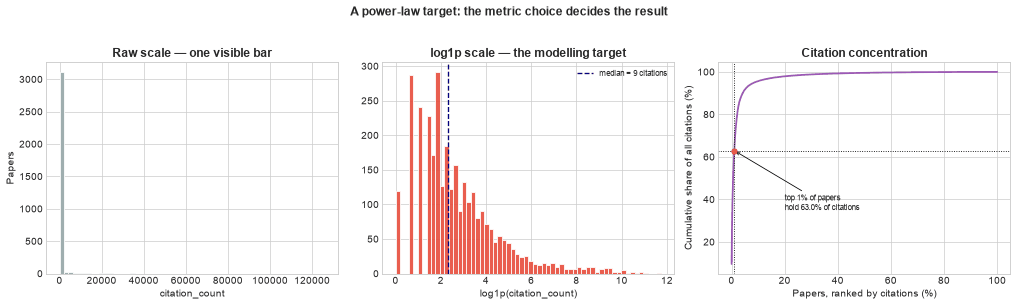

Median citations   : 9
Mean citations     : 409
Max citations      : 126,171
90th percentile    : 167
99th percentile    : 10,300
Top 32 papers (1%) hold 63.0% of all citations.

Therefore raw-scale MAE is a report on 32 rows, and every metric below uses log1p.


In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.6))

ax1.hist(df[TARGET_COL], bins=60, color="#95a5a6", alpha=0.9, edgecolor="white")
ax1.set_xlabel("citation_count")
ax1.set_ylabel("Papers")
ax1.set_title("Raw scale — one visible bar", fontweight="bold")

ax2.hist(df["log_citations"], bins=60, color="#e74c3c", alpha=0.9, edgecolor="white")
ax2.axvline(df["log_citations"].median(), color="navy", linestyle="--",
            label=f"median = {df[TARGET_COL].median():.0f} citations")
ax2.set_xlabel("log1p(citation_count)")
ax2.set_title("log1p scale — the modelling target", fontweight="bold")
ax2.legend(fontsize=9)

ordered = df[TARGET_COL].sort_values(ascending=False).values
share = np.cumsum(ordered) / ordered.sum()
pct_papers = np.arange(1, len(ordered) + 1) / len(ordered) * 100
ax3.plot(pct_papers, share * 100, color="#9b59b6", linewidth=2)
top1 = share[int(len(ordered) * 0.01)] * 100
ax3.axvline(1, color="black", linestyle=":", linewidth=1)
ax3.axhline(top1, color="black", linestyle=":", linewidth=1)
ax3.scatter([1], [top1], color="#e74c3c", zorder=5)
ax3.annotate(f"top 1% of papers\nhold {top1:.1f}% of citations",
             xy=(1, top1), xytext=(20, top1 - 28), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="black", lw=0.9))
ax3.set_xlabel("Papers, ranked by citations (%)")
ax3.set_ylabel("Cumulative share of all citations (%)")
ax3.set_title("Citation concentration", fontweight="bold")

plt.suptitle("A power-law target: the metric choice decides the result",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

n_top = int(len(df) * 0.01)
print(f"Median citations   : {df[TARGET_COL].median():,.0f}")
print(f"Mean citations     : {df[TARGET_COL].mean():,.0f}")
print(f"Max citations      : {df[TARGET_COL].max():,.0f}")
print(f"90th percentile    : {df[TARGET_COL].quantile(0.9):,.0f}")
print(f"99th percentile    : {df[TARGET_COL].quantile(0.99):,.0f}")
print(f"Top {n_top} papers ({n_top / len(df):.0%}) hold {top1:.1f}% of all citations.")
print()
print("Therefore raw-scale MAE is a report on 32 rows, and every metric below uses log1p.")

## 6. Leakage & Feasibility Audit <a id='audit'></a>

Two questions, asked in order. First: does any column contain the target? Second, and
more important here: is the target *reachable* from the columns that remain?

The first answer is reassuring and the second is not. Nothing in this table is derived
from `citation_count` — but `paper_id` carries the publication date in its text, and the
target is right-censored in the two most recent years, which is what breaks the realistic
split.

In [7]:
# Question 1: does anything encode the target?
NUMERIC_CANDIDATES = ["year", "month", "num_authors"]
audit = df[NUMERIC_CANDIDATES + ["has_code", "is_survey"]].copy()
audit["has_code"] = audit["has_code"].astype(int)
audit["is_survey"] = audit["is_survey"].astype(int)
audit["log_citations"] = df["log_citations"]

print("Correlation with log1p(citation_count) — every numeric / boolean column:")
print("-" * 62)
target_corr = audit.corr()["log_citations"].drop("log_citations")
for name, value in target_corr.sort_values(key=abs, ascending=False).items():
    flag = "  <-- LEAK" if abs(value) > 0.9 else ""
    print(f"  {name:<16} {value:>+7.4f}{flag}")
print()
print("No column exceeds |r| = 0.35, so nothing here is the target in disguise.")
print()

# Question 2: what does paper_id contain?
stamp = df["paper_id"].str.split(".").str[1]
year_match = (stamp.str[:4].astype(int) == df["year"]).mean()
month_match = (stamp.str[4:].astype(int) == df["month"]).mean()
print("But paper_id is not an opaque key:")
print(f"  format          : {df['paper_id'].iloc[0]}  (arxiv.YYYYMM.NNNNN)")
print(f"  embedded year matches the year column  : {year_match:.1%}")
print(f"  embedded month matches the month column: {month_match:.1%}")
print("  Therefore any hash, prefix or target-encoding of paper_id smuggles the")
print("  publication date back in — including into a split that removed it on purpose.")

Correlation with log1p(citation_count) — every numeric / boolean column:
--------------------------------------------------------------
  year             -0.3188
  is_survey        +0.0731
  has_code         -0.0311
  num_authors      +0.0286
  month            -0.0096

No column exceeds |r| = 0.35, so nothing here is the target in disguise.

But paper_id is not an opaque key:
  format          : arxiv.202008.00686  (arxiv.YYYYMM.NNNNN)
  embedded year matches the year column  : 100.0%
  embedded month matches the month column: 100.0%
  Therefore any hash, prefix or target-encoding of paper_id smuggles the
  publication date back in — including into a split that removed it on purpose.


In [8]:
# Question 3: is the target even reachable? Check the censoring.
by_year = df.groupby("year")[TARGET_COL].agg(["size", "median", "max"])

print("Right-censoring in the two most recent years")
print("=" * 62)
print(f"{'year':<8} {'papers':>8} {'median':>9} {'max':>12}")
print("-" * 62)
for year, row in by_year.iterrows():
    mark = "  <-- capped" if row["max"] < 1000 else ""
    print(f"{year:<8} {row['size']:>8,.0f} {row['median']:>9,.0f} {row['max']:>12,.0f}{mark}")
print("-" * 62)
uncensored_max = by_year.loc[by_year.index <= 2023, "max"].max()
print(f"Highest citation count up to 2023 : {uncensored_max:,.0f}")
print(f"Highest in 2024                   : {by_year.loc[2024, 'max']:,.0f}")
print(f"Highest in 2025                   : {by_year.loc[2025, 'max']:,.0f}")
print()
print("The generator truncates recent years, so a model trained on 2018-2023 has never")
print("seen the range it is asked to predict. That makes the time-ordered split in")
print("section 10 a test of extrapolation into an impossible region, not of skill.")

Right-censoring in the two most recent years
year       papers    median          max
--------------------------------------------------------------
2018          192        27       53,077
2019          256        20      126,171
2020          320        15       14,395
2021          416        12       22,444
2022          512        10       27,479
2023          576         8       61,386
2024          544         5          146  <-- capped
2025          384         3           30  <-- capped
--------------------------------------------------------------
Highest citation count up to 2023 : 126,171
Highest in 2024                   : 146
Highest in 2025                   : 30

The generator truncates recent years, so a model trained on 2018-2023 has never
seen the range it is asked to predict. That makes the time-ordered split in
section 10 a test of extrapolation into an impossible region, not of skill.


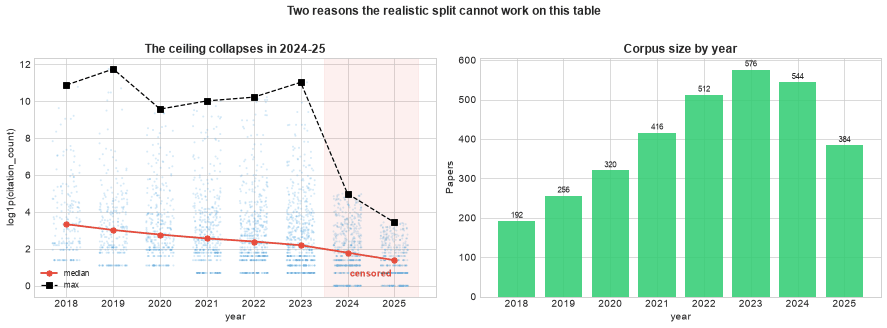

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df["year"] + np.random.uniform(-0.3, 0.3, len(df)),
            df["log_citations"], s=5, alpha=0.2, color="#3498db", edgecolors="none")
ax1.plot(by_year.index, np.log1p(by_year["median"]), color="#e74c3c",
         marker="o", linewidth=2, label="median")
ax1.plot(by_year.index, np.log1p(by_year["max"]), color="black",
         marker="s", linewidth=1.4, linestyle="--", label="max")
ax1.axvspan(2023.5, 2025.5, color="#e74c3c", alpha=0.08)
ax1.text(2024.5, 0.5, "censored", ha="center", fontsize=10, color="#c0392b",
         fontweight="bold")
ax1.set_xlabel("year")
ax1.set_ylabel("log1p(citation_count)")
ax1.set_title("The ceiling collapses in 2024-25", fontweight="bold")
ax1.legend(fontsize=9)

bars = ax2.bar(by_year.index.astype(str), by_year["size"], color="#2ecc71", alpha=0.85)
for bar, v in zip(bars, by_year["size"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 8, f"{v:,.0f}",
             ha="center", fontsize=9)
ax2.set_xlabel("year")
ax2.set_ylabel("Papers")
ax2.set_title("Corpus size by year", fontweight="bold")

plt.suptitle("Two reasons the realistic split cannot work on this table",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Distributions <a id='distributions'></a>

`num_authors` and `month` are near-uniform and carry no relationship to anything, which
Section 10 will confirm by measurement rather than by eye.

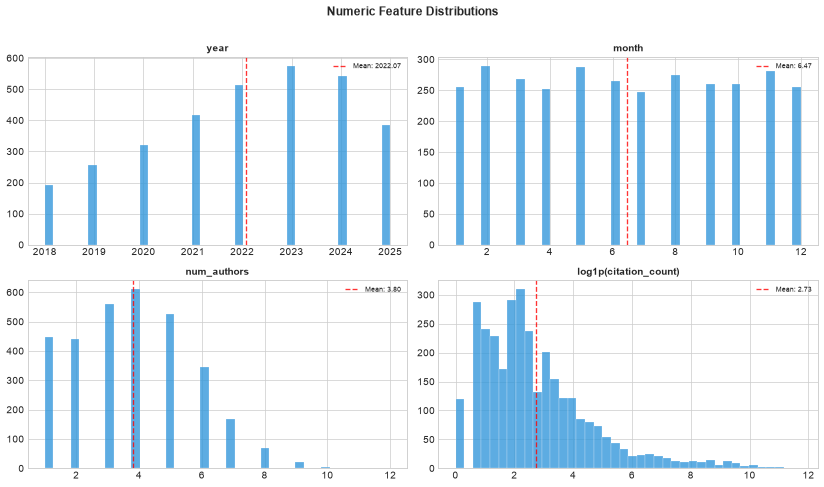

In [10]:
NUMERIC_COLS = ["year", "month", "num_authors", "citation_count"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
axes = axes.flatten()
for ax, col in zip(axes, NUMERIC_COLS):
    values = df["log_citations"] if col == "citation_count" else df[col]
    label = "log1p(citation_count)" if col == "citation_count" else col
    ax.hist(values, bins=40, color="#3498db", alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(values.mean(), color="red", linestyle="--", alpha=0.8,
               label=f"Mean: {values.mean():.2f}")
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 8. Categoricals <a id='categorical'></a>

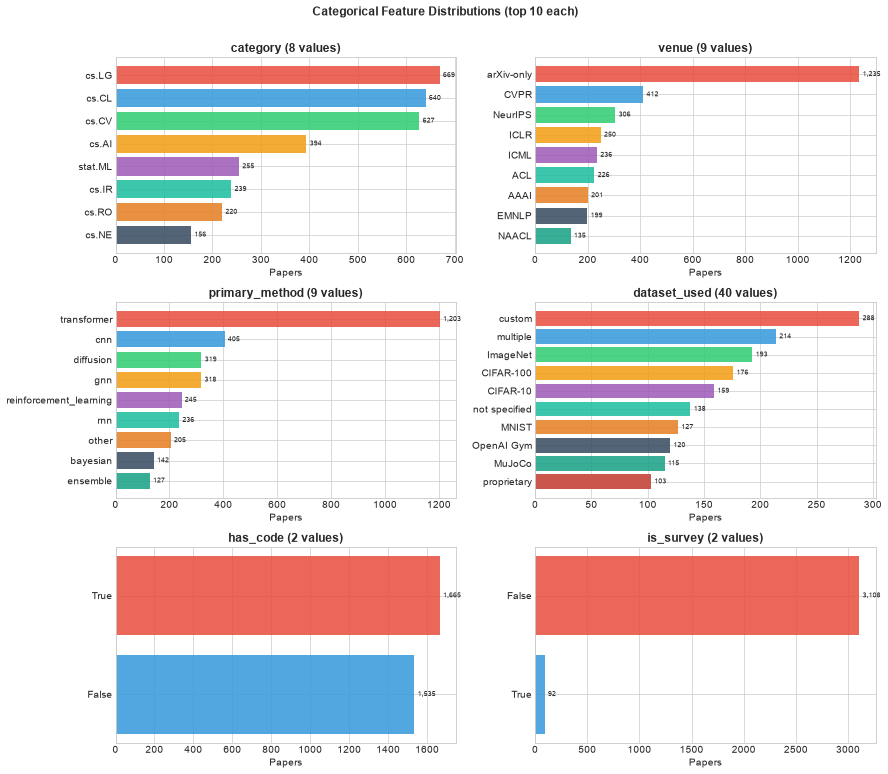

In [11]:
CAT_COLS = ["category", "venue", "primary_method", "dataset_used", "has_code", "is_survey"]
palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
           "#1abc9c", "#e67e22", "#34495e", "#16a085", "#c0392b"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    counts = df[col].value_counts().head(10)
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=[palette[i % len(palette)] for i in range(len(counts))],
                   alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(f"{col} ({df[col].nunique()} values)", fontweight="bold")
    ax.set_xlabel("Papers")
    for bar, val in zip(bars, counts.values):
        ax.text(val + counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=8)

plt.suptitle("Categorical Feature Distributions (top 10 each)", fontsize=14,
             fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

## 9. Correlations <a id='correlations'></a>

There are only three numeric columns besides the target, so a heatmap here is thin by
construction. That thinness is itself informative: everything that might predict
citations in this table is categorical, and Pearson correlation cannot see it. Section 10
uses a gradient-boosted model instead, which can.

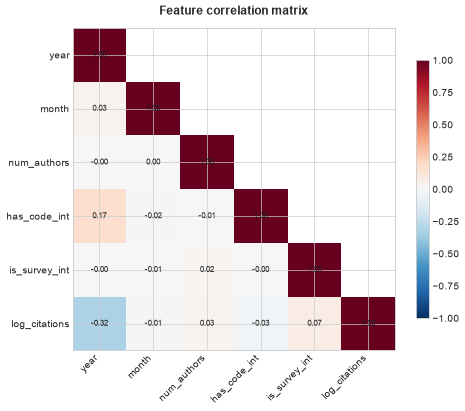

Strongest |correlation| with the target: 0.319
Nothing here is close to a usable linear predictor.


In [12]:
CORR_COLS = ["year", "month", "num_authors", "has_code_int", "is_survey_int",
             "log_citations"]
df["has_code_int"] = df["has_code"].astype(int)
df["is_survey_int"] = df["is_survey"].astype(int)
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(corr.mask(mask), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(CORR_COLS)))
ax.set_yticklabels(CORR_COLS)
for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

strongest = corr["log_citations"].drop("log_citations").abs().max()
print(f"Strongest |correlation| with the target: {strongest:.3f}")
print("Nothing here is close to a usable linear predictor.")

## 10. Can Citations Be Predicted at All? <a id='model'></a>

Three feature sets, two splits, one baseline. The three feature sets are chosen to
separate signal from noise:

- **generator columns** — `year`, `venue`, `is_survey`. These are the three inputs the
  citation count is actually built from.
- **all metadata** — the above plus `num_authors`, `has_code`, `month`, `category`,
  `primary_method`, `subcategory`, `dataset_used`.
- **everything except the generator columns** — the seven remaining metadata columns
  alone, as a negative control.

If the extra seven carry information, the middle row should beat the first. If they are
noise, it should lose to it.

In [13]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, cross_val_predict

GENERATOR_COLS = ["year", "venue", "is_survey"]
EXTRA_COLS = ["num_authors", "has_code", "month", "category",
              "primary_method", "subcategory", "dataset_used"]

FEATURE_SETS = {
    "generator columns (year, venue, is_survey)": GENERATOR_COLS,
    "all metadata columns": GENERATOR_COLS + EXTRA_COLS,
    "everything EXCEPT the generator columns": EXTRA_COLS,
}
y = df["log_citations"]


def fit_score(columns, split):
    X = df[columns].copy()
    cats = [c for c in columns if X[c].dtype == object or str(X[c].dtype) == "str"]
    for c in cats:
        X[c] = X[c].astype("category")
    model = HistGradientBoostingRegressor(
        random_state=SEED,
        categorical_features=[X.columns.get_loc(c) for c in cats] or None,
    )
    if split == "random":
        pred = cross_val_predict(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED))
        return mean_absolute_error(y, pred)
    train = df["year"] <= 2023
    model.fit(X[train], y[train])
    return mean_absolute_error(y[~train], model.predict(X[~train]))


results = {}
print(f"{'feature set':<44} {'random 5-fold':>15} {'time-ordered':>15}")
print("-" * 78)
baselines = {
    "random": mean_absolute_error(y, np.full(len(y), y.median())),
    "time": mean_absolute_error(
        y[df["year"] > 2023],
        np.full((df["year"] > 2023).sum(), y[df["year"] <= 2023].median()),
    ),
}
print(f"{'BASELINE: always predict the median':<44} "
      f"{baselines['random']:>15.4f} {baselines['time']:>15.4f}")
print("-" * 78)
for label, cols in FEATURE_SETS.items():
    scores = {split: fit_score(cols, split) for split in ("random", "time")}
    results[label] = scores
    print(f"{label:<44} {scores['random']:>15.4f} {scores['time']:>15.4f}")
print("-" * 78)
print("Lower is better. MAE is on log1p, so 1.30 means the typical prediction is")
print("off by roughly a factor of e^1.3 ~ 3.7 in citation count.")
print()
best_random = min(r["random"] for r in results.values())
best_time = min(r["time"] for r in results.values())
print(f"Best model, random split : {best_random:.4f} vs baseline {baselines['random']:.4f} "
      f"({1 - best_random / baselines['random']:+.1%})")
print(f"Best model, time split   : {best_time:.4f} vs baseline {baselines['time']:.4f} "
      f"({1 - best_time / baselines['time']:+.1%})")

feature set                                    random 5-fold    time-ordered
------------------------------------------------------------------------------
BASELINE: always predict the median                   1.3752          1.2433
------------------------------------------------------------------------------
generator columns (year, venue, is_survey)            1.3181          1.3891
all metadata columns                                  1.3841          1.5046
everything EXCEPT the generator columns               1.5163          1.6345
------------------------------------------------------------------------------
Lower is better. MAE is on log1p, so 1.30 means the typical prediction is
off by roughly a factor of e^1.3 ~ 3.7 in citation count.

Best model, random split : 1.3181 vs baseline 1.3752 (+4.2%)
Best model, time split   : 1.3891 vs baseline 1.2433 (-11.7%)


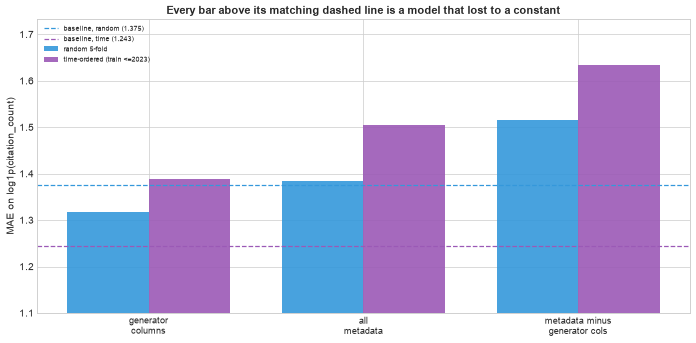

Reading it: on the random split one configuration squeezes 4% below the baseline
by learning that older papers have more citations. On the time-ordered split that
knowledge is useless, because the held-out years are exactly the censored ones,
therefore every model is worse than predicting a single number.


In [14]:
fig, ax = plt.subplots(figsize=(11, 5.5))

labels = list(results)
x = np.arange(len(labels))
random_scores = [results[k]["random"] for k in labels]
time_scores = [results[k]["time"] for k in labels]

ax.bar(x - 0.19, random_scores, 0.38, label="random 5-fold", color="#3498db", alpha=0.9)
ax.bar(x + 0.19, time_scores, 0.38, label="time-ordered (train <=2023)",
       color="#9b59b6", alpha=0.9)
ax.axhline(baselines["random"], color="#3498db", linestyle="--", linewidth=1.4,
           label=f"baseline, random ({baselines['random']:.3f})")
ax.axhline(baselines["time"], color="#9b59b6", linestyle="--", linewidth=1.4,
           label=f"baseline, time ({baselines['time']:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(["generator\ncolumns", "all\nmetadata", "metadata minus\ngenerator cols"],
                   fontsize=10)
ax.set_ylabel("MAE on log1p(citation_count)")
ax.set_ylim(1.1, max(time_scores + random_scores) * 1.06)
ax.set_title("Every bar above its matching dashed line is a model that lost to a constant",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

print("Reading it: on the random split one configuration squeezes 4% below the baseline")
print("by learning that older papers have more citations. On the time-ordered split that")
print("knowledge is useless, because the held-out years are exactly the censored ones,")
print("therefore every model is worse than predicting a single number.")

## 11. What This Table Is Actually Good For <a id='trends'></a>

A negative result on per-paper prediction is not a negative result on the dataset. The
aggregate structure is real, well sampled and exactly what the dataset name advertises —
method mix over time, code-release rates, and venue effects on typical citation counts.
Those hold up because they are medians over hundreds of papers rather than predictions
about individual ones.

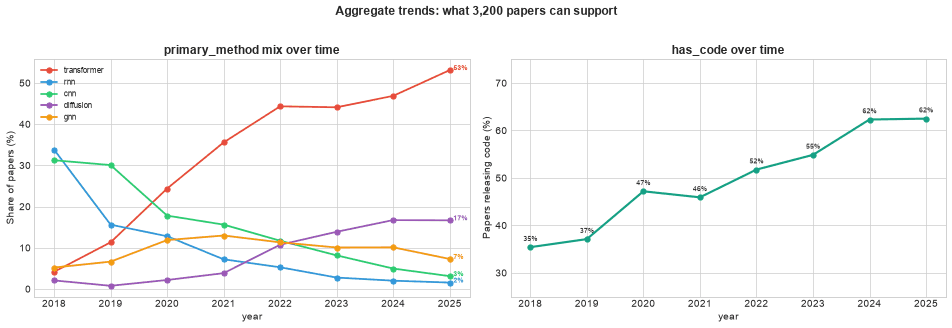

Method share, first year vs last:
  transformer      4.2% (2018) ->  53.1% (2025)    +49.0 pts
  rnn             33.9% (2018) ->   1.6% (2025)    -32.3 pts
  cnn             31.2% (2018) ->   3.1% (2025)    -28.1 pts
  diffusion        2.1% (2018) ->  16.7% (2025)    +14.6 pts
  gnn              5.2% (2018) ->   7.3% (2025)     +2.1 pts

Code release   35.4% (2018) ->  62.5% (2025)    +27.1 pts


In [15]:
method_share = pd.crosstab(df["year"], df["primary_method"], normalize="index") * 100
code_share = df.groupby("year")["has_code"].mean() * 100

TRACKED = ["transformer", "rnn", "cnn", "diffusion", "gnn"]
colors = {"transformer": "#e74c3c", "rnn": "#3498db", "cnn": "#2ecc71",
          "diffusion": "#9b59b6", "gnn": "#f39c12"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for method in TRACKED:
    ax1.plot(method_share.index, method_share[method], marker="o", linewidth=2,
             color=colors[method], label=method)
    ax1.annotate(f"{method_share[method].iloc[-1]:.0f}%",
                 xy=(method_share.index[-1], method_share[method].iloc[-1]),
                 xytext=(4, 0), textcoords="offset points", fontsize=8,
                 color=colors[method], fontweight="bold")
ax1.set_xlabel("year")
ax1.set_ylabel("Share of papers (%)")
ax1.set_title("primary_method mix over time", fontweight="bold")
ax1.legend(fontsize=9)

ax2.plot(code_share.index, code_share.values, marker="o", linewidth=2.4, color="#16a085")
for year, value in code_share.items():
    ax2.annotate(f"{value:.0f}%", xy=(year, value), xytext=(0, 7),
                 textcoords="offset points", ha="center", fontsize=8)
ax2.set_xlabel("year")
ax2.set_ylabel("Papers releasing code (%)")
ax2.set_ylim(25, 75)
ax2.set_title("has_code over time", fontweight="bold")

plt.suptitle("Aggregate trends: what 3,200 papers can support", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Method share, first year vs last:")
for method in TRACKED:
    first, last = method_share[method].iloc[0], method_share[method].iloc[-1]
    print(f"  {method:<14} {first:>5.1f}% (2018) -> {last:>5.1f}% (2025)   {last - first:>+6.1f} pts")
print()
print(f"Code release  {code_share.iloc[0]:>5.1f}% (2018) -> {code_share.iloc[-1]:>5.1f}% (2025)   "
      f"{code_share.iloc[-1] - code_share.iloc[0]:>+6.1f} pts")

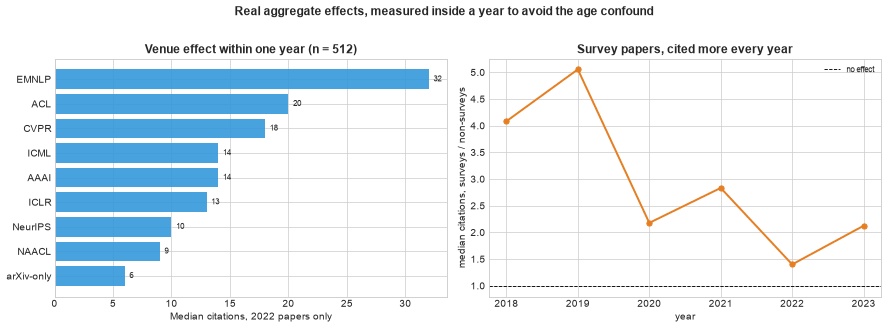

In 2022: EMNLP median 32 citations, arXiv-only median 6 (5.3x)
Survey multiplier, 2018-2023: 1.40x to 5.06x (median 2.51x)
Surveys are only 2.9% of the corpus (92 papers), so per-year estimates are noisy —
the direction is consistent, the exact multiplier is not.


In [16]:
# Venue and survey effects, measured within a single year so the age trend cannot
# confound them. 2022 is the last year with a full sample and no citation censoring.
YEAR = 2022
snapshot = df[df["year"] == YEAR]
venue_median = snapshot.groupby("venue")[TARGET_COL].median().sort_values()
survey_ratio = (df[df["year"] <= 2023]
                .groupby(["year", "is_survey"])[TARGET_COL].median().unstack())
survey_ratio["ratio"] = survey_ratio[True] / survey_ratio[False]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.barh(venue_median.index, venue_median.values, color="#3498db", alpha=0.9)
ax1.set_xlabel(f"Median citations, {YEAR} papers only")
ax1.set_title(f"Venue effect within one year (n = {len(snapshot)})", fontweight="bold")
for bar, v in zip(bars, venue_median.values):
    ax1.text(v + 0.4, bar.get_y() + bar.get_height() / 2, f"{v:,.0f}",
             va="center", fontsize=9)

ax2.plot(survey_ratio.index, survey_ratio["ratio"], marker="o", linewidth=2.2,
         color="#e67e22")
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1, label="no effect")
ax2.set_xlabel("year")
ax2.set_ylabel("median citations, surveys / non-surveys")
ax2.set_title("Survey papers, cited more every year", fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Real aggregate effects, measured inside a year to avoid the age confound",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"In {YEAR}: {venue_median.index[-1]} median {venue_median.iloc[-1]:,.0f} citations, "
      f"{venue_median.index[0]} median {venue_median.iloc[0]:,.0f} "
      f"({venue_median.iloc[-1] / venue_median.iloc[0]:.1f}x)")
print(f"Survey multiplier, 2018-2023: {survey_ratio['ratio'].min():.2f}x to "
      f"{survey_ratio['ratio'].max():.2f}x (median {survey_ratio['ratio'].median():.2f}x)")
print(f"Surveys are only {df['is_survey'].mean():.1%} of the corpus "
      f"({int(df['is_survey'].sum())} papers), so per-year estimates are noisy —")
print("the direction is consistent, the exact multiplier is not.")

## 12. Evaluation Readiness <a id='evaluation'></a>

In [17]:
print("Evaluation readiness checklist")
print("=" * 72)
print(f"Target        : {TARGET_COL}, modelled as log1p")
print(f"Task          : {MODELING_TASK}")
print(f"Metric        : {PRIMARY_METRIC}")
print(f"Baseline      : MAE {baselines['random']:.4f} random / {baselines['time']:.4f} time-ordered")
print()
print("Honest verdict on the supervised task:")
print(f"  Best random-split model  : {best_random:.4f}  ({1 - best_random / baselines['random']:+.1%} vs baseline)")
print(f"  Best time-split model    : {best_time:.4f}  ({1 - best_time / baselines['time']:+.1%} vs baseline)")
print("  Per-paper citation prediction is NOT supported by this table. Any notebook")
print("  reporting a good score here should be checked for a random split plus year.")
print()
print("Traps, in the order they bite:")
print("  1. Raw-scale metrics. 1% of papers hold 62% of the citations.")
print("  2. paper_id encodes YYYYMM. Do not hash it into a time-split model.")
print("  3. Citations are censored in 2024-25. Train-on-past, test-on-future asks")
print("     for extrapolation into a range the generator forbade.")
print("  4. Seven of the ten metadata columns are noise; including them costs")
print(f"     {results['all metadata columns']['random'] - results['generator columns (year, venue, is_survey)']['random']:+.4f} MAE on the random split.")
print()
print("What the table DOES support:")
print("  - Method-mix and code-release trend analysis over 8 years")
print("  - Within-year venue and survey effects on median citations")
print("  - Text work on 3,200 abstracts (template-generated, so shallow but consistent)")

Evaluation readiness checklist
Target        : citation_count, modelled as log1p
Task          : regression
Metric        : MAE on log1p(citation_count)
Baseline      : MAE 1.3752 random / 1.2433 time-ordered

Honest verdict on the supervised task:
  Best random-split model  : 1.3181  (+4.2% vs baseline)
  Best time-split model    : 1.3891  (-11.7% vs baseline)
  Per-paper citation prediction is NOT supported by this table. Any notebook
  reporting a good score here should be checked for a random split plus year.

Traps, in the order they bite:
  1. Raw-scale metrics. 1% of papers hold 62% of the citations.
  2. paper_id encodes YYYYMM. Do not hash it into a time-split model.
  3. Citations are censored in 2024-25. Train-on-past, test-on-future asks
     for extrapolation into a range the generator forbade.
  4. Seven of the ten metadata columns are noise; including them costs
     +0.0660 MAE on the random split.

What the table DOES support:
  - Method-mix and code-release trend anal

## 13. Key Findings & Takeaways <a id='findings'></a>

Every number below is printed by a cell above. Nothing is asserted that the notebook does
not also compute.

### Finding 1 — the advertised supervised task does not work, and saying so is the result

Best honest configuration scores MAE(log1p) **1.3181** against a median baseline of
**1.3752** on a random split — a 4.2% edge — and **1.3891** against a baseline of
**1.2433** on the time-ordered split, which is an 11.7% *loss*. The 4% edge on the random
split comes almost entirely from `year`, and a random split lets the model see papers
from the same year on both sides of the fold. **Therefore** the only split that
corresponds to a real use case is the one where no model beats a constant.

### Finding 2 — nothing leaks, but `paper_id` smuggles the date back in

No column correlates with `log1p(citation_count)` above **|r| = 0.35**, so this table has
no target-derived features — a genuine difference from most of the datasets in this
collection. The subtler risk is `paper_id`: its `arxiv.YYYYMM.NNNNN` format reproduces
the `year` and `month` columns for **100%** of rows, so treating it as an opaque
identifier and hashing it puts publication time back into a model that removed it.

### Finding 3 — seven of the ten metadata columns are noise, and they cost you

Adding `num_authors`, `has_code`, `month`, `category`, `primary_method`, `subcategory`
and `dataset_used` to the three columns that matter moves random-split MAE from
**1.3181 to 1.3841** — worse. On their own those seven score **1.5163**, well below the
baseline. This is a useful negative control: it means feature engineering on this table
is not merely unproductive but actively harmful, **because** a boosted model given noise
will fit it.

### Finding 4 — the target is censored, which is what actually breaks the realistic split

Maximum citation count is **61,386** in 2023, **146** in 2024 and **30** in 2025. The
generator caps recent years to imitate citation lag, and the effect is that a model
trained on 2018-2023 is asked to predict into a range its training data declares
impossible. The trade-off worth naming: the same censoring that makes this table
*realistic* as a picture of citation lag makes it *unusable* for the forward-looking
prediction task the metadata invites.

### Finding 5 — the aggregate trends are solid, and they are the point

Measured over hundreds of papers per year rather than one at a time: `transformer` rises
from **4.2%** of papers in 2018 to **53.1%** in 2025, `rnn` falls from **33.9%** to
**1.6%**, `cnn` from **31.2%** to **3.1%**, and `diffusion` climbs from **2.1%** to
**16.7%**. Code release goes from **35.4%** to **62.5%**. Inside 2022 alone — so the age
effect cannot confound it — EMNLP papers have a median of **32** citations against
**6** for arXiv-only, and survey papers out-cite non-surveys in every year from 2018 to
2023.

### Limitations and caveats

- **This data is synthetic.** Citation counts are a power-law draw scaled by year, venue
  and survey status. The trends resemble the real literature because they were written to,
  not because they were observed.
- **The corpus shrinks after 2023** — 576 papers in 2023, 544 in 2024, 384 in 2025. That
  is a generator artefact, not a decline in publishing, and it makes the last two points
  of every trend line less reliable than the rest.
- **Only 92 papers are surveys** (2.9% of the corpus), so the per-year survey multiplier
  swings between 1.40× and 5.06×. The direction is consistent across all six uncensored
  years; the magnitude is not estimable from this sample.
- **Titles repeat.** 2,757 unique titles across 3,200 papers, because they are drawn from
  templates. Deduplicating on title would silently drop 443 rows.
- **A negative result is not proof of impossibility.** It shows that these ten columns
  under these two splits cannot predict citations. Abstract text, which this notebook did
  not model, is untested.

### Conclusion and next steps

The habit this dataset teaches is running the baseline first. A constant predictor takes
one line, and here it beats every model under the only split that corresponds to a real
question. Most notebooks would never have found that out, **because** they report a
random-split score and never compare it to anything.

Recommended next steps:

- **Model the trends instead of the papers.** Fit method share as a function of year and
  forecast 2026 — an aggregate target with hundreds of rows behind each point, which is
  the grain this data actually supports.
- **Try the abstracts.** TF-IDF or a sentence embedding over 3,200 abstracts is the one
  feature space this notebook left untested; the honest expectation is that it fails too,
  since the generator does not link abstract text to citation count, but that is worth
  confirming rather than assuming.
- **Treat 2024-25 as censored and model it that way.** Survival analysis or a Tobit model
  handles a known ceiling properly, and this table is a clean teaching case for it.
- **Reproduce Section 10 on real arXiv + Semantic Scholar data.** The interesting question
  is whether the negative result survives contact with real citations, or whether it is an
  artefact of the generator's independent power-law draw.

*The data is synthetic and generated by a seeded script. It is built for teaching,
benchmarking and prototyping, not for bibliometric conclusions about AI research.*